In [2]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_euclid")

Loaded 64 objects


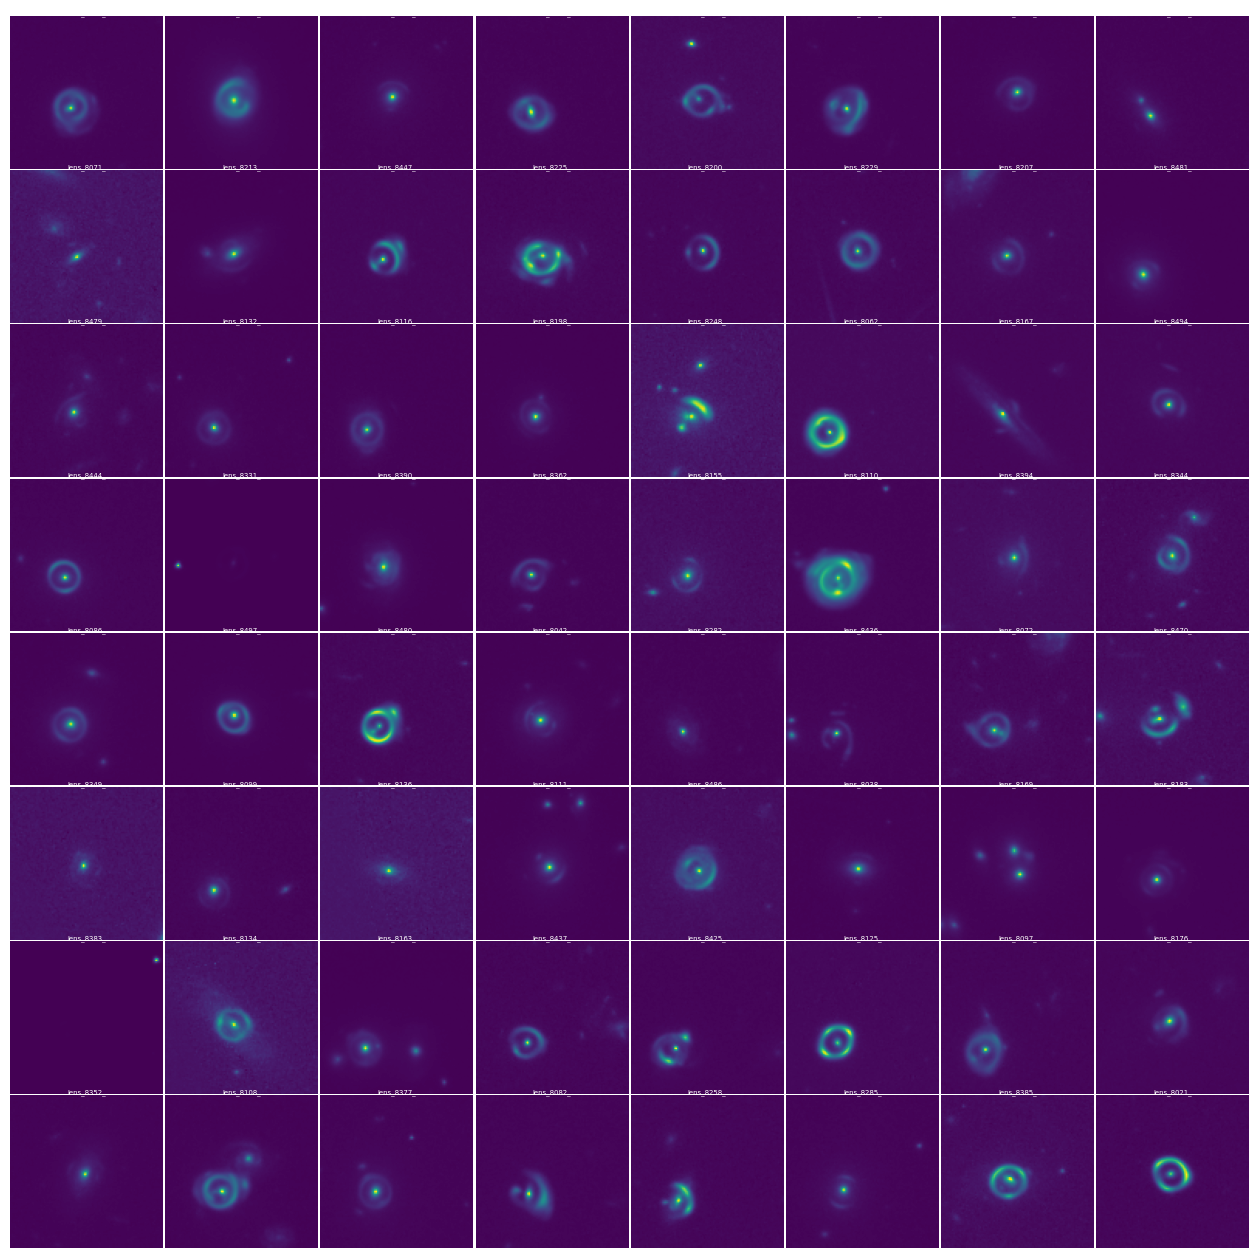

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import random

base_dir = "/home/rcanameras/data/mock_lenses_euclid/final_euclidmodel_5e2_17"
files_files = [f for f in os.listdir(base_dir) if".fits" in f]
folders = files_files[:64]   # ← fix: define folders

def load_band(path):
    with fits.open(path) as hdul:
        img = hdul[1].data.astype(float)
    # img = np.nan_to_num(img)
    # # img = (img - np.nanmin(img))/(np.nanmax(img)) 
    # # img =  np.arcsinh(10 * img)/np.arcsinh(10)
    # p1, p99 = np.percentile(img, [0, 99.996])
    # if p99 > p1:
    #     img = np.clip(img, p1, p99)
    #     img = (img - p1) / (p99 - p1)
    # else:
    #     img[:] = 0
    # # img = (img)/(np.nanmax(img))
    # # img = np.arcsinh(img)
    # img = np.sqrt(img)
    # # img = np.sqrt(10 * img)/np.sqrt(10)
    # # img =  np.arcsinh(10 * img)/np.arcsinh(10)
    return img


images = []
labels = []

for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    img = load_band(folder_path)
    crop = 0
    # if h > 2 * crop and w > 2 * crop:
    # img = img[crop:-crop, crop:-crop]

    images.append(img)
    labels.append(folder)

print(f"Loaded {len(images)} objects")

# --- Plot ---
ncols, nrows = 8, 8
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))
plt.subplots_adjust(wspace=0.01, hspace=0.01)

for ax in axes.flat:
    ax.axis("off")
w1 = 40
for i, ax in enumerate(axes.flat):
    if i < len(images):
        c = random.randint(0, w1-20)
        ax.imshow(images[i][w1+c:-w1+c,w1+c:-w1+c] , origin="lower")
        ax.set_title(labels[i][:10], fontsize=5, pad=1, color="white")  # optional ID label

# plt.savefig("euclid_color_grid.png", dpi=150, bbox_inches="tight",
            # facecolor="black")
plt.show()

In [4]:
import pandas as pd

df = pd.read_csv('mock_lenses_euclid.csv', index_col = 0)

In [5]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

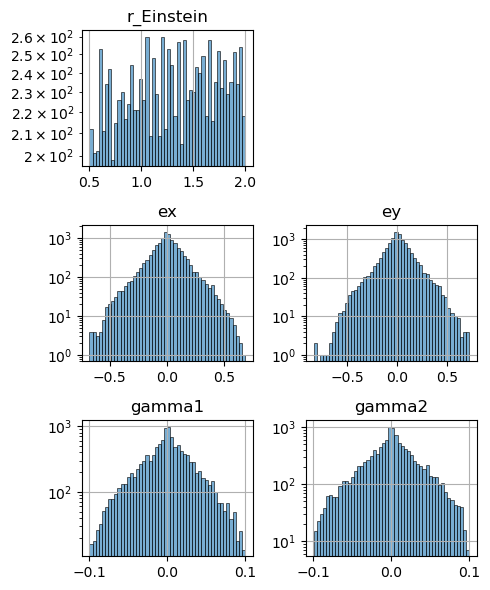

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(5, 6))
axes = axes.flatten()   
columns = ["r_Einstein", "ex", "ey", "gamma1", "gamma2"]
poss = [0,2,3,4,5]

for i, col in enumerate(columns):
    axes[poss[i]].hist(df[col], bins=50, alpha=0.6, log=True, edgecolor='black',linewidth=0.7)
    axes[poss[i]].set_title(col)
    axes[poss[i]].grid(True)

# axes[-2].axis("off")
axes[1].axis("off")
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/dataset_small.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [8]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [9]:
df_full = df.merge(df_im, on = "objID", how = 'left')
df_sample = df_full#.sample(n=2000, random_state=42)
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']
dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())
dff = dff.sample(frac=1, random_state=42)

In [10]:
dff

,r_Einstein,gamma1,gamma2,ex,ey
location,,,,,
final_euclidmodel_5e2_11/lens_5428_source_917_r_3.fits,0.534726,0.541530,0.457798,0.542368,0.646485
final_euclidmodel_5e2_8/lens_3939_source_7085_r_2.fits,0.693093,0.459633,0.488433,0.554145,0.480223
final_euclidmodel_5e2_15/lens_7191_source_1668_r_2.fits,0.374757,0.399485,0.545373,0.401015,0.684458
final_euclidmodel_5e2_15/lens_7095_source_7283_r_1.fits,0.415009,0.053512,0.540382,0.568476,0.466987
final_euclidmodel_5e2_12/lens_5824_source_980_r_2.fits,0.518282,0.572118,0.478440,0.578064,0.527537
...,...,...,...,...,...
final_euclidmodel_5e2_24/lens_11649_source_958_r_1.fits,0.019075,0.637011,0.681072,0.520534,0.550671
final_euclidmodel_5e2_11/lens_5236_source_3252_r_1.fits,0.553392,0.502341,0.503472,0.503519,0.528860
final_euclidmodel_5e2_11/lens_5439_source_7387_r_0.fits,0.561656,0.375217,0.248307,0.392110,0.406973


In [11]:
import torch
from astropy.io import fits
import numpy as np

def save_fits_as_tensor(arr, save_path):
    # arr is dimension 4 
    tensor = torch.tensor(arr, dtype=torch.float32)
    torch.save(tensor, save_path)

In [12]:
path_image = "/net/CLUSTER/VAULT/users/rcanameras/data/mock_lenses_euclid/"
save_path = "/net/CLUSTER/VAULT/users/mbatt/data_euclid_simu/"

In [48]:
# rm -f /net/CLUSTER/VAULT/users/mbatt/data_euclid_simu/*

In [ ]:
import random
from tqdm import tqdm
import os

w1 = 40 # image will be of dimension w2-w1 x w2-w1
LL = [f for f in os.listdir(save_path)]

for ima_file in tqdm(df_sample.location):
    # if ima_file.split('/')[1] + '.pt' not in LL:
    with fits.open(path_image + ima_file) as hdul:
        c = random.randint(0, w1-20)
        images = [hdul[i].data[w1+c:-w1+c,w1+c:-w1+c] for i in range(1, len(hdul))]
        arr = np.stack(images, axis=0)
        if images[1].sum() <=200:
            save_fits_as_tensor(arr, save_path + ima_file.split('/')[1] + ".pt")

 75%|██████████████████████████████████████████████████████████████▍                    | 8708/11574 [01:21<00:28, 102.00it/s]

In [ ]:
print(len([f for f in os.listdir(save_path)]))

In [14]:
os.chdir("/home/mbatt/gravitational_lensing")

In [15]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [16]:
class LensDataset_euclid(Dataset):
    def __init__(self, df, path_tensor_folder):
        self.df = df
        self.path = path_tensor_folder

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tensor_path = os.path.join(self.path, row.name.split('/')[1] + '.pt')
        # with fits.open(tensor_path, memmap=True) as hdul:
        #     img = np.stack([
        #         hdul[1].data.astype(np.float32, copy=False),
        #         hdul[2].data.astype(np.float32, copy=False),
        #     ])
    
        # x = torch.from_numpy(img)
        x = torch.load(tensor_path)
        
        x = torch.clamp(x, min=0)
        # x_min = x.amin(dim=(1, 2), keepdim=True)
        # x_max = x.amax(dim=(1, 2), keepdim=True)
        # # print(x_min.shape, x_max.shape)
        # x = (x - x_min) / (x_max - x_min + 1e-8)
        x = torch.sqrt(x)
        y = torch.tensor(row.values, dtype=torch.float32)
        return (x[0], x[1]), (y[3:], row.name)

    def split_data(self, training_pct, test_pct, batch_size):
 
        n = len(self)
        test_size = int(test_pct * n)
        remaining_size = n - test_size

        generator = torch.Generator().manual_seed(42)

        remaining_dataset, test_dataset = random_split(
            self,
            [remaining_size, test_size],
            generator=generator)

        train_size = int(training_pct * n)
        val_size = remaining_size - train_size

        train_dataset, val_dataset = random_split(
            remaining_dataset,
            [train_size, val_size])
     
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=3)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=3)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=3)
        
        return train_loader, val_loader, test_loader

In [17]:
import torch
from torch.utils.data import random_split

path_tensor = "/net/CLUSTER/VAULT/users/mbatt/data_euclid_simu/"
full_dataset = LensDataset_euclid(dff, path_tensor)
# test_loader = DataLoader(full_dataset, batch_size=32, shuffle=False, num_workers=3)

# path_tensor = "/home/mbatt/data"
# full_dataset = LensDataset_UNet(dff, path_tensor)
train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, #20% for test
                                                                batch_size = 32)

In [18]:
model = UNetThenResNet()
# model = ResNetHoliSmokes()

In [19]:
model.model_name

'UNetThenResNet'

In [20]:
# vv = viewer(model)
# vv.show_model()

In [21]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 4,618,083
Trainable parameters: 4,618,083


In [22]:
from process_training import Trainer

In [23]:
from process_training import Trainer
import warnings
warnings.filterwarnings("ignore")

In [24]:
Train_model = Trainer(model = model,
                      learning_rate = 1e-3,
                      scheduler_coef = 0.1                  
)

In [25]:
Train_model.run_unet_resnet(epochs = 100,
                training_set = train_loader, 
                validation_set = val_loader)

Epoch 1: train=0.0056, val=0.0033
Epoch 2: train=0.0021, val=0.0016
Epoch 3: train=0.0017, val=0.0019
Epoch 4: train=0.0014, val=0.0016
Epoch 5: train=0.0012, val=0.0013
Epoch 6: train=0.0012, val=0.0013


KeyboardInterrupt: 

In [ ]:
print(eeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee)

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.chdir("/home/mbatt/gravitational_lensing")
# os.chdir("/home/mbatt/")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# checkpoint = torch.load(f"{model.model_name}_16.pth", map_location=device)
# checkpoint = torch.load(f"{model.model_name}_22.pth", map_location=device)
checkpoint = torch.load(f"ResNetHoliSmokes_euclid_5.pth", map_location=device)
checkpoint = torch.load(f"UNetThenResNet_euclid_9.pth", map_location=device)

model.load_state_dict(checkpoint["model"])
optimizer.load_state_dict(checkpoint["optimizer"])

start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]


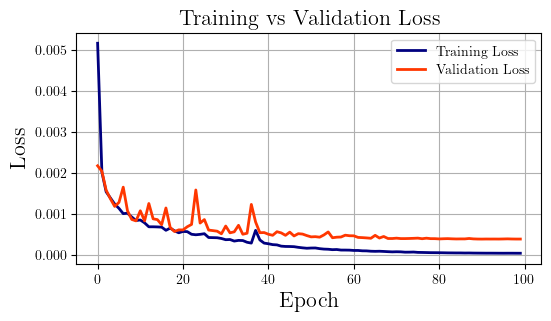

In [26]:
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

plt.figure(figsize=(6,3))
plt.plot(train_losses, label="Training Loss", color = '#00007F', linewidth = 2)
plt.plot(val_losses, label="Validation Loss", color = '#FF3700', linewidth = 2)
plt.xlabel("Epoch", fontsize = 16)
plt.ylabel("Loss", fontsize = 16)
plt.title("Training vs Validation Loss", fontsize = 16)
plt.legend()
plt.grid(True)
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_loss.png", dpi=300, bbox_inches="tight")
plt.show()


In [27]:
import time
model.eval()
preds_mu = []
preds_std = []
targets = []
epistemic = []

criterion = nn.MSELoss(reduction="none")
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        xb, xout = xb[0].to(device), xb[1].to(device)
        xb = xb.unsqueeze(1)
        yb, paths = yb[0].to(device), yb[1]

        optimizer.zero_grad()

        # ---- Forward pass ----
        # Sampling 
        # start = time.time()
        # out_lens = model.forward_unet(xb)
        # muu = model.forward_resnet(out_lens)
        muu = model(xb)
        preds_mu.append(muu.cpu())
        targets.append(yb.cpu())

# concatenate all batches
preds_mu = np.concatenate(preds_mu, axis = 0)      # shape (N, 5)
# preds_std = np.concatenate(preds_std, axis = 0)
# epistemic = np.concatenate(epistemic, axis = 0)
targets = np.concatenate(targets, axis = 0)  # shape (N, 5)

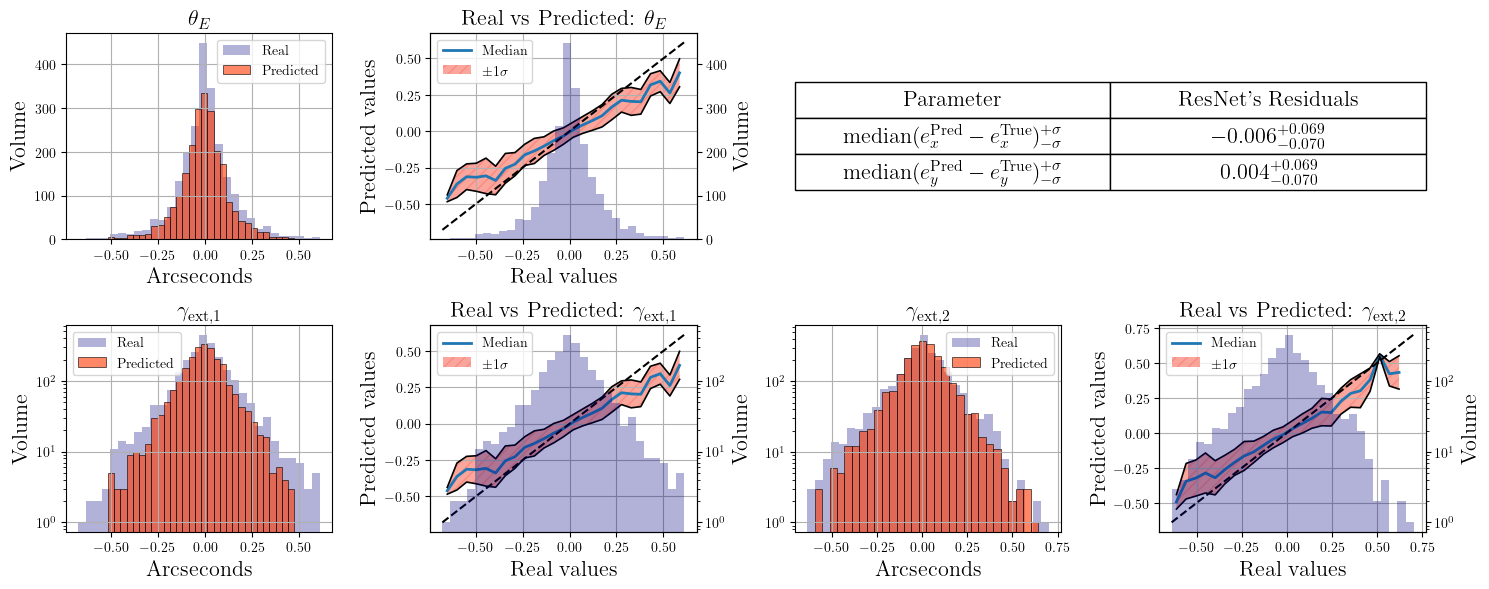

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# # Min/max used for normalization
# df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
# df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

df_min = df_sample[["ex", "ey"]].min().values
df_max = df_sample[["ex", "ey"]].max().values

# # # Convert to numpy
# y_true = df_uncertainties[["r_Einstein_t_true",	"gamma1_true",	"gamma2_true",	"ex_true",	"ey_true"]].values
# y_pred = df_uncertainties[["r_Einstein_t_pred",	"gamma1_pred",	"gamma2_pred",	"ex_pred",	"ey_pred"]].values

y_true = targets 
y_pred = preds_mu 

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

y_true_denorm = np.column_stack((y_true_denorm[:, 0], y_true_denorm))
y_pred_denorm = np.column_stack((y_pred_denorm[:, 0], y_pred_denorm))

error_denorm = y_pred_denorm - y_true_denorm

MMedians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = MMedians - p16
sigma_plus  = p84 - MMedians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
param_names = [r"$\theta_E$", r"$\gamma_{\mathrm{ext,1}}$", r"$\gamma_{\mathrm{ext,2}}$", r"$e_x$", r"$e_y$"]

fig = plt.figure(figsize=(15, 6))
# places = [(1,2), (5,6), (7,8), (9,10), (11,12)]
places = [(1,2), (5,6), (7,8)]

for i in range(3):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Histogram comparison
    plt.subplot(2, 4, places[i][0])
    if i == 0: 
        plt.hist(y_true_denorm[:, i], bins=30, alpha=0.3, label="Real", color = '#00007F')
        plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7, color = '#FF3700')
    else : 
        plt.hist(y_true_denorm[:, i], bins=30, alpha=0.3, label="Real", log = True, color = '#00007F')
        plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7, log = True, color = '#FF3700')
    plt.title(f"{param_names[i]}", fontsize = 16)
    plt.xlabel('Arcseconds', fontsize = 16)
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
#     plt.subplot(5, 2, 2*i + 2)

    # Extract the variables
    x = y_true_denorm[:, i]
    y = y_pred_denorm[:, i]
    
    # Define number of bins
    nbins = 25

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(2, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Predicted values", fontsize = 16)
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="$\pm 1 \sigma$"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    
    # 1:1 line
    # min_val = min(x.min(), y.min())
    # max_val = max(x.max(), y.max())
    x_diag = np.linspace(x.min(), x.max(), 100)
    ax1.plot(x_diag, x_diag, "k--", lw=1.5)
    if i == 0 :
        ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3, color = '#00007F')
    else :
        ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3, log = True, color = '#00007F')
    ax2.set_ylabel("Volume", fontsize = 16)
    
    ax1.set_xlabel("Real values", fontsize = 16)
    ax1.legend()
    plt.title(f"Real vs Predicted: {param_names[i]}", fontsize = 16)
#     plt.grid(True)
#     plt.legend()


PPP = [(1,2), (5,6), (9,10)]
PPP = [(1,2), (5,6)]
for jj in PPP:
    ax1 = plt.subplot(2, 4,  jj[0])
    ax1.set_ylabel('Volume', fontsize = 16)

    # --- Add text box with denormalised stats ---
# ax = plt.subplot(3, 4, 3)
# ax.axis("off")
# data = [
#     [r"median$(\theta_E^{\mathrm{Pred}}- \theta_E^{\mathrm{True}})^{+ \sigma}_{- \sigma}$", fr"${MMedians[0]:.3f}_{{-{sigma_minus[0]:.3f}}}^{{+{sigma_plus[0]:.3f}}}$"],
#     [r"median$(e_x^{\mathrm{Pred}} - e_x^{\mathrm{True}})^{+\sigma}_{-\sigma}$", fr"${MMedians[3]:.3f}_{{-{sigma_minus[3]:.3f}}}^{{+{sigma_plus[3]:.3f}}}$"],
#     [r"median$(e_y^{\mathrm{Pred}} - e_y^{\mathrm{True}})^{+\sigma}_{-\sigma}$", fr"${MMedians[4]:.3f}_{{-{sigma_minus[4]:.3f}}}^{{+{sigma_plus[4]:.3f}}}$"],
#     ["median$(\gamma_{\mathrm{ext, 1}}^{\mathrm{Pred}} - \gamma_{\mathrm{ext,1}}^{\mathrm{True}})^{+\sigma}_{-\sigma}$", fr"${MMedians[1]:.3f}_{{-{sigma_minus[1]:.3f}}}^{{+{sigma_plus[1]:.3f}}}$"],
#     ["median$(\gamma_{\mathrm{ext,2}}^{\mathrm{Pred}} - \gamma_{\mathrm{ext, 2}}^{\mathrm{True}})^{+\sigma}_{-\sigma}$", fr"${MMedians[2]:.3f}_{{-{sigma_minus[2]:.3f}}}^{{+{sigma_plus[2]:.3f}}}$"],
# ]

data = [
    [r"median$(e_x^{\mathrm{Pred}} - e_x^{\mathrm{True}})^{+\sigma}_{-\sigma}$", fr"${MMedians[1]:.3f}_{{-{sigma_minus[1]:.3f}}}^{{+{sigma_plus[1]:.3f}}}$"],
    [r"median$(e_y^{\mathrm{Pred}} - e_y^{\mathrm{True}})^{+\sigma}_{-\sigma}$", fr"${MMedians[2]:.3f}_{{-{sigma_minus[2]:.3f}}}^{{+{sigma_plus[2]:.3f}}}$"],]

gs = fig.add_gridspec(2, 4)
ax_table = fig.add_subplot(gs[0, 2:4])  
ax_table.axis("off")

table = ax_table.table(
    cellText=data,
    colLabels=["Parameter", "ResNet's Residuals"],
    loc="center",
    cellLoc="center",   # <-- centers text in ALL cells
    colLoc="center"     # <-- centers column labels
)

# Style cells
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        
table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1, 2.2)
plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/unet_resnet_results_ex_only.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
y_true_denorm[:,0].arrange(0,).shape

AttributeError: 'numpy.ndarray' object has no attribute 'arrange'

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # # Convert to numpy
# y_true = df_uncertainties[["r_Einstein_t_true",	"gamma1_true",	"gamma2_true",	"ex_true",	"ey_true"]].values
# y_pred = df_uncertainties[["r_Einstein_t_pred",	"gamma1_pred",	"gamma2_pred",	"ex_pred",	"ey_pred"]].values

y_true = targets 
y_pred = preds_mu 

# --- DENORMALIZATION ---
y_true = y_true * (df_max - df_min) + df_min
y_pred = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
param_names = [r"$\Delta \ \theta_E$", r"$\Delta \ \gamma_1$", r"$\Delta \ \gamma_2$", r"$\Delta \ e_x$", r"$\Delta \ e_y$"]

y_true = np.array(y_true)
y_pred = np.array(y_pred)

residuals = y_pred - y_true   # shape: (N, 5)
n_params = residuals.shape[1]

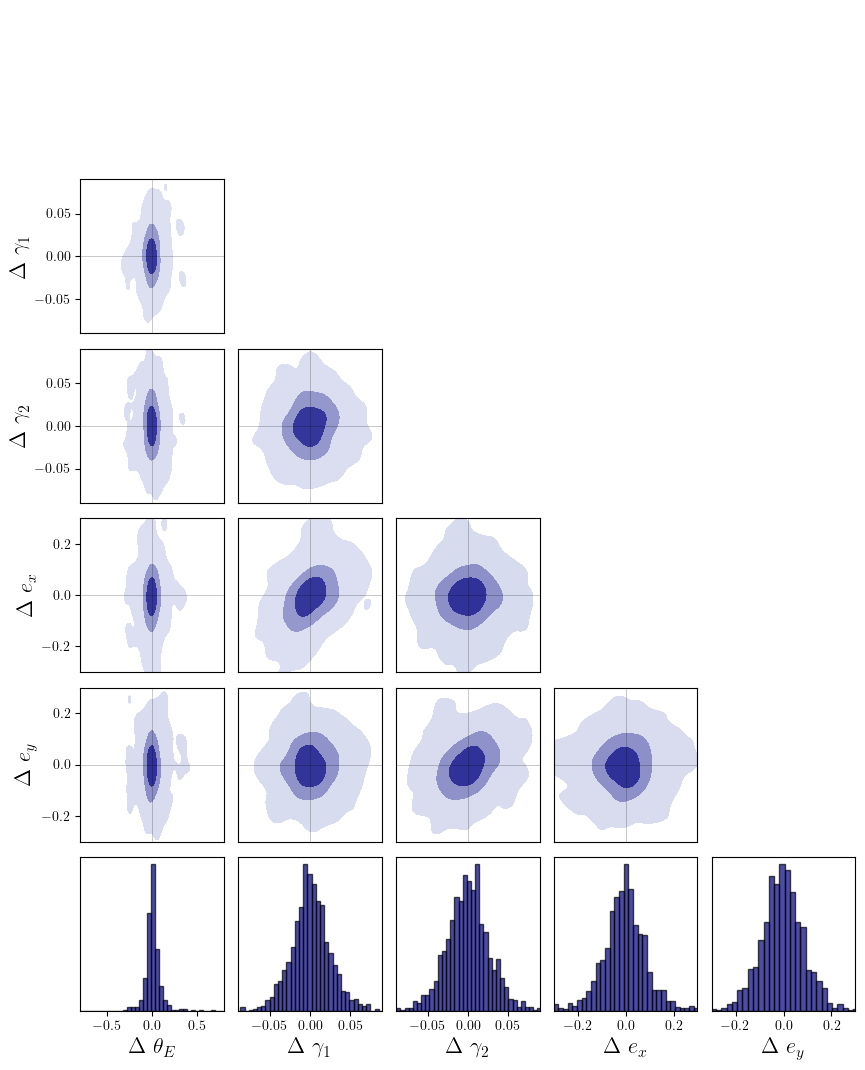

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

from matplotlib.colors import LinearSegmentedColormap

custom_blues = LinearSegmentedColormap.from_list(
    "custom_blues",
    ["#f7fbff", "#00007F"]  # light → your exact dark blue
)

fig, axes = plt.subplots(n_params + 1, n_params, figsize=(10, 13))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

for i in range(n_params):
    for j in range(n_params):

        ax = axes[i, j]

        if i > j:
            # KDE contours
            sns.kdeplot(
                x=residuals[:, j],
                y=residuals[:, i],
                levels=4,
                linewidths=1.2,
                color = 'black',
                cmap=custom_blues, # cmap="Blues", #Blues #00007F
                fill=True,
                alpha=1,
                ax=ax
            )

            # zero reference lines (VERY useful visually)
            ax.axhline(0, color="black", lw=0.5, alpha=0.3)
            ax.axvline(0, color="black", lw=0.5, alpha=0.3)
        else:
            ax.axis("off")
        if i < 3:
            ax.set_ylim([-0.09, 0.09])
        else : 
            ax.set_ylim([-0.3, 0.3])
        if j == 0:
            ax.set_xlim([-0.8, 0.8])
        elif j < 3:
            ax.set_xlim([-0.09, 0.09])
        else:
            ax.set_xlim([-0.3, 0.3])

        # axis labels (FIXED CONDITION)
        if i == n_params :
            ax.set_xlabel(param_names[j], fontsize = 20)
        else:
            ax.set_xticks([])

        if j == 0 and i != j:
            ax.set_ylabel(param_names[i], fontsize = 16)
        else:
            ax.set_yticks([])
            

# bottom row histograms
for k in range(n_params):
    ax = axes[-1, k]
    ax.hist(residuals[:, k], bins=40, edgecolor="black", color = '#00007F', alpha = 0.7)
    ax.set_xlabel(param_names[k], fontsize = 16)
    ax.set_yticks([])
    if k == 0:
        ax.set_xlim([-0.8, 0.8])
    elif k < 3:
        ax.set_xlim([-0.09, 0.09])
    else:
        ax.set_xlim([-0.3, 0.3])
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/degenerency.png", dpi=300, bbox_inches="tight")
plt.show()

<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_196917/1228079212.py:56: SyntaxWarning: invalid escape sequence '\s'
  f"$+ \sigma$ = {sigma_plus[i]:.4f}\n"
/tmp/ipykernel_196917/1228079212.py:57: SyntaxWarning: invalid escape sequence '\s'
  f"$- \sigma$ = {sigma_minus[i]:.4f}"


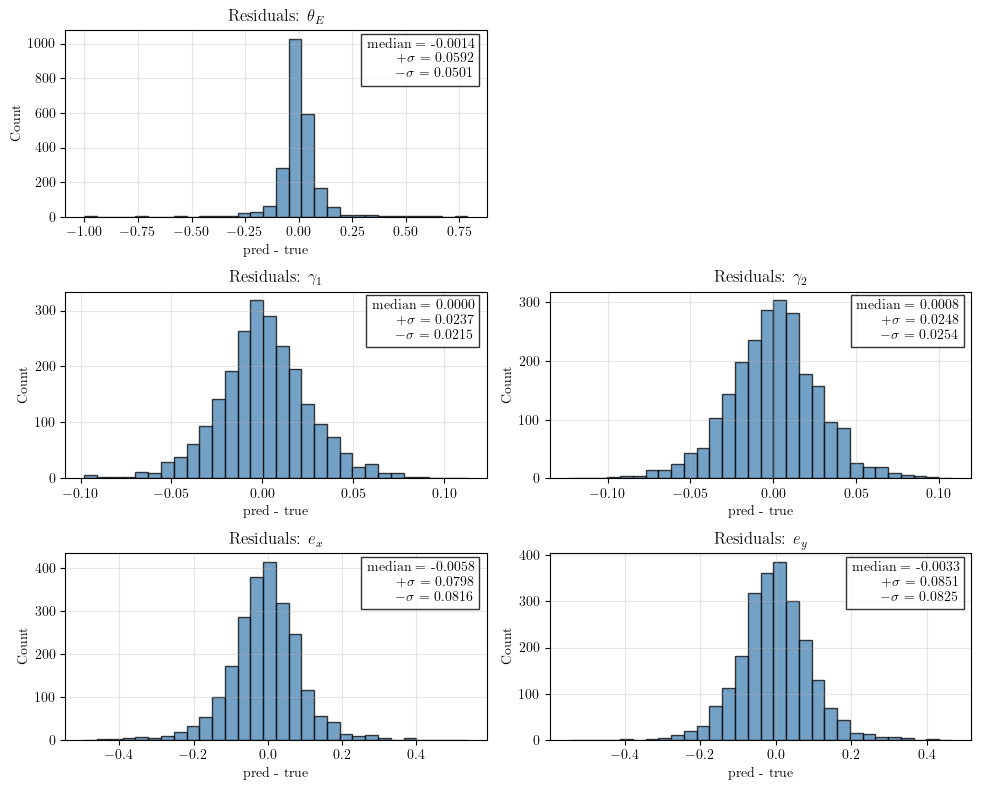

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # # Convert to numpy
# y_true = df_uncertainties[["r_Einstein_t_true",	"gamma1_true",	"gamma2_true",	"ex_true",	"ey_true"]].values
# y_pred = df_uncertainties[["r_Einstein_t_pred",	"gamma1_pred",	"gamma2_pred",	"ex_pred",	"ey_pred"]].values


y_true = targets 
y_pred = preds_mu 

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

# --- Compute denormalised errors ---
error_denorm = y_pred_denorm - y_true_denorm

# --- Asymmetric statistics ---
medians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
param_names = [r"$\theta_E$", r"$\gamma_1$", r"$\gamma_2$", r"$e_x$", r"$e_y$"]

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()  
poss = [1,3,4,5,6]

for i in range(error_denorm.shape[1]):
    plt.subplot(3, 2, poss[i])
    plt.hist(error_denorm[:, i], bins=30, alpha=0.75,
             color="steelblue", edgecolor="black")
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("pred - true")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # --- Add text box with denormalised stats ---
    text = (
        f"median = {medians[i]:.4f}\n"
        f"$+ \sigma$ = {sigma_plus[i]:.4f}\n"
        f"$- \sigma$ = {sigma_minus[i]:.4f}"
    )

    plt.text(
        0.97, 0.95, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )

plt.tight_layout()
axes[1].axis("off")
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_hist_residus.png", dpi=300, bbox_inches="tight")
plt.show()

In [1]:
def rms(x):
    return torch.sqrt(torch.mean(x**2, dim=(-2, -1)))

def compute_noise(Liste, image, squarre):
    # Extract 5x5 corners
    tl = image[..., 0:squarre, 0:squarre]
    tr = image[..., 0:squarre, -squarre:]
    bl = image[..., -squarre:, 0:squarre]
    br = image[..., -squarre:, -squarre:]

    # RMS per corner → [B, 4]
    rms_tl = rms(tl)
    rms_tr = rms(tr)
    rms_bl = rms(bl)
    rms_br = rms(br)

    # Stack → [B, 4, 4]
    rms_all = torch.stack([rms_tl, rms_tr, rms_bl, rms_br], dim=-1)

    # Minimum RMS across corners → [B, 4]
    rms_min = rms_all.min(dim=-1).values

    Liste.append(rms_min.cpu())
    return Liste

In [32]:
model.eval()

Noise_t = []
Noise_p = []
Signal_t = []
Signal_p = []

squarre = 20
criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:
        xb, xout = xb[0].to(device), xb[1].to(device)
        xb = xb.unsqueeze(1)
        xout = xout.unsqueeze(1)
        yb, _ = yb[0].to(device), yb[1]

        optimizer.zero_grad()

        # ---- Forward pass ----
        out_lens = model.forward_unet(xb)
#         out_lens = torch.cat([out_lens, xb - out_lens], dim=1)
        outputs = model.forward_resnet(out_lens)
        
        Noise_t = compute_noise(Noise_t, xb, squarre)
        Noise_p = compute_noise(Noise_p, out_lens, squarre)

        # Signal = sum of all pixels in xout → [B, 4]
        signal_batch = out_lens.sum(dim=(-1, -2))
        Signal_p.append(signal_batch.cpu())

        signal_batch = xout.sum(dim=(-1, -2))
        Signal_t.append(signal_batch.cpu())

# Concatenate all batches
Noise_p = torch.cat(Noise_p, dim=0) 
Noise_t = torch.cat(Noise_t, dim=0) 
# Noise[Noise == 0] = 0.2 # shape [N, 4]
Signal_p = torch.cat(Signal_p, dim=0)  # shape [N, 4]
Signal_t = torch.cat(Signal_t, dim=0) # shape [N, 4]

# Compute ratio
Ratio_p = Signal_p / Noise_p
Ratio_t = Signal_t / Noise_t

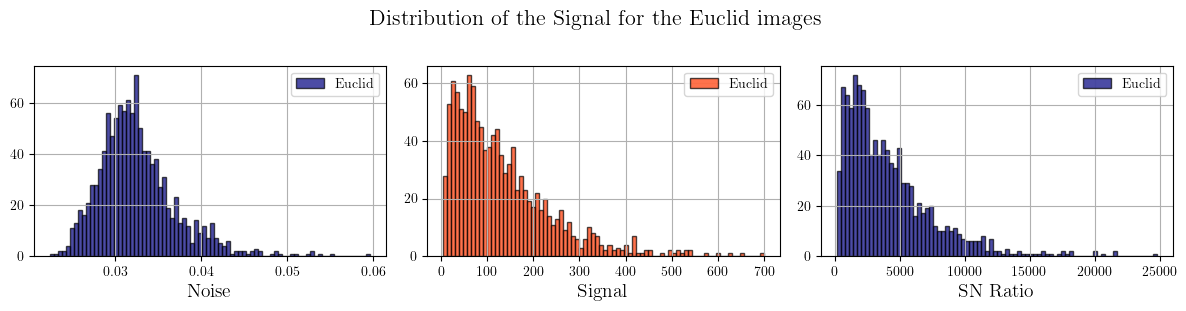

In [33]:
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]


fig, axis = plt.subplots(1,3, figsize = (12,3))
ax = axis[0]
ax.hist(Noise_t[Noise_t < 0.06], bins=80, alpha=0.7, label = 'Euclid', edgecolor = 'black', color = '#00007F')
ax.grid(True)
ax.set_xlabel('Noise', fontsize=14)
ax.legend()

ax = axis[1]
ax.hist(Signal_t[Signal_t < 700], bins=80, alpha=0.7, label = f'Euclid', edgecolor = 'black', color = '#FF3700')
ax.grid(True)
ax.set_xlabel('Signal',fontsize=14)
ax.legend()

ax = axis[2]
ax.hist(Ratio_t[Ratio_t < 30000], bins=80, alpha=0.7, label = f'Euclid', edgecolor = 'black', color = '#00007F')
ax.grid(True)
ax.set_xlabel('SN Ratio',fontsize=14)
ax.legend()

fig.suptitle("Distribution of the Signal for the Euclid images",
             fontsize=16, y=1.02)
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/sn_ratio.png", dpi=300, bbox_inches="tight")

plt.show()

    

In [34]:
from skimage.metrics import structural_similarity as ssim

model.eval()
preds_img = []
targets_img = []
inpute_img = []

pred_para = []
target_para = []
worsts_t = []
worsts_p = []

similarity = []
paths_list = []
i = 0

def normalize(y):
    M = np.array(y)
    return M/M.sum()

with torch.no_grad():
    for xb, yb in test_loader:
        xb, xout = xb[0].to(device), xb[1].to(device)
        xb = xb.unsqueeze(1)
        yb, paths = yb[0].to(device), yb[1]

        optimizer.zero_grad()

        # ---- Forward pass ----
        out_lens = model.forward_unet(xb)
        outputs = model.forward_resnet(out_lens)

        simi = []
        for k in range(len(xout)):
            ss = []
            M1 = normalize(xout[k].cpu())
            M2 = normalize(out_lens[k].cpu())
            # ss.append(ssim(M1, M2, data_range=1.0, full=True)[0])
            diff = M1 - M2
            mse = np.sqrt((diff**2).mean())
            similarity.append(mse)
            
        errors = np.abs(outputs.cpu()[:, 0] - yb.cpu()[:, 0])
        idx_bad = np.where(errors > (1.35)/(2.49995857 - 0.75001659))[0]
        
        if len(idx_bad) > 0:
            for i in idx_bad:
                preds_img.append(out_lens.cpu()[i])
                targets_img.append(xout.cpu()[i])
                inpute_img.append(xb.cpu()[i])
                paths_list.append(paths[i])
                worsts_t.append(yb.cpu()[i])
                worsts_p.append(outputs.cpu()[i])

        errors = np.abs(outputs.cpu()[:, 0] - yb.cpu()[:, 0])
        idx_bad = np.where(errors < 0.00004/(2.49995857 - 0.75001659))[0]
        
        if len(idx_bad) > 0:
            for i in idx_bad:
                preds_img.append(out_lens.cpu()[i])
                targets_img.append(xout.cpu()[i])
                inpute_img.append(xb.cpu()[i])
                paths_list.append(paths[i])
                worsts_t.append(yb.cpu()[i])
                worsts_p.append(outputs.cpu()[i])
        
        pred_para.append(outputs.cpu())
        target_para.append(yb.cpu())

# concatenate all batches
preds_img = torch.cat(preds_img)      
targets_img = torch.cat(targets_img)  
inpute_img = torch.cat(inpute_img)

# paths_list = torch.cat(paths_list)
target_para = torch.cat(target_para)  
pred_para = torch.cat(pred_para)
worsts_t = torch.stack(worsts_t)   # shape (K, 5)
worsts_p = torch.stack(worsts_p)
similarity = np.stack(similarity)

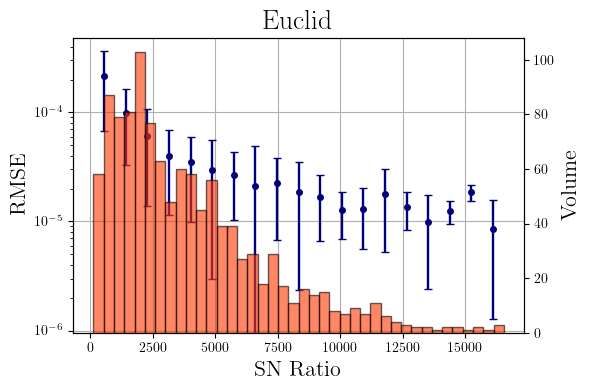

In [37]:
from matplotlib.ticker import FuncFormatter

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

fig, axes = plt.subplots(figsize=(6, 4))

twin_axes = []

ax = axes

# --- your data prep ---
x = Ratio_t.cpu().numpy()
mask = (x < 17000)
x = x[mask]

residuals = similarity
residuals = residuals[mask[:,0]]

# --- binning ---
bins = np.linspace(x.min(), x.max(), 20)
bin_idx = np.digitize(x, bins)

medians = []
sigma1_low = []
sigma1_high = []
sigma3_low = []
sigma3_high = []
bin_centers = []

for b in range(1, len(bins)):
    bin_mask = bin_idx == b
    if np.sum(bin_mask) < 3:
        continue

    r = residuals[bin_mask]
    med = np.median(r)
    std = np.std(r)

    medians.append(med)
    sigma1_low.append(med - std)
    sigma1_high.append(med + std)
    sigma3_low.append(med - 3*std)
    sigma3_high.append(med + 3*std)
    bin_centers.append((bins[b] + bins[b-1]) / 2)

bin_centers = np.array(bin_centers)

# --- left axis ---
ax.errorbar(
bin_centers, medians,
yerr=[np.array(medians) - np.array(sigma1_low),
      np.array(sigma1_high) - np.array(medians)],
fmt='o', color='#00007F', markersize=4, linewidth=1.2,
ecolor='#00007F', elinewidth=1.7, capsize=3, label='Median $\pm 1 \sigma$')# , color = '#FF3700') 00007F
ax.grid(True)

# --- right axis (histogram) ---
ax2 = ax.twinx()
twin_axes.append(ax2)
ax2.hist(x, bins=40, edgecolor='black', alpha=0.6, color = '#FF3700')
ax.set_yscale("log")
axes.set_title(f'Euclid', fontsize = 20)

# share all right y-axes
for ax2 in twin_axes[1:]:
    ax2.sharey(twin_axes[3])

Bands = ['g', 'r', 'i', 'z']
axes.set_xlabel('SN Ratio', fontsize = 16)
axes.set_ylabel('RMSE', fontsize = 16)
ax2.set_ylabel('Volume', fontsize = 16)
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/snr_rmse.png", dpi=300, bbox_inches="tight")
plt.show()


In [52]:
def cheat(imgi):
    H = []
    for j in range(len(imgi)):
        L = []
        for i in range(4):
            img = imgi[j,i,:,:].cpu()
            img = abs(img)
            img = np.nan_to_num(img)
            # p1, p99 = np.percentile(img, [0, 99.996])
            p1, p99 = np.percentile(img, [0, 99.996])
            if p99 > p1:
                img = np.clip(img, p1, p99)
                img = (img - p1) / (p99 - p1)
            else:
                img[:] = 0
            img = np.sqrt(img)
            L.append(img)
        N = np.stack(L, axis = 0)
        H.append(N)
    H = np.stack(H, axis = 0)
    return torch.tensor(H, dtype=torch.float32)

In [29]:
model.eval()
preds = []
targets = []
lens_only = []
paths = []
image = []
criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        xb = xb.to(device)
        ms = xb[:,0,:,:].mean(dim=(1, 2))
        image.append(ms)
        # xb = xb[:,-1,:,:]
        # xb = xb[0].to(device)
        yb, ps = yb[0].to(device), yb[1]

        # out_lens = model.forward_unet(xb)
        # outputs = model.forward_resnet(out_lens)
        outputs = model(xb)
        
        preds.append(outputs.cpu())
        targets.append(yb.cpu())
        paths += ps

# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)
means = torch.cat(image)
df_final = pd.DataFrame({'Objid' : paths, 'Prediction_r_einstein' : preds.cpu().numpy()[:,0], 'Target_r_einstein' : targets.cpu().numpy()[:,0]})

/tmp/ipykernel_827556/4048788566.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_827556/4048788566.py:12: FutureWarning: You 

In [38]:
path_tensor = "/home/mbatt/data"
full_dataset = LensDataset_UNet(dff, path_tensor)
train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

In [39]:
i = 0
image = []
for kk in test_loader:
    ms = kk[0][0][:,0,:,:].mean(dim=(1, 2))
    image.append(ms)
simuu = torch.cat(image)


/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/deep_learning_models.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/net/CLUSTER/VAULT

KeyboardInterrupt: 

In [ ]:
len(simuu.cpu().numpy())

In [ ]:
import matplotlib.pyplot as plt
plt.hist(simuu.cpu().numpy(), bins = 100, edgecolor = 'black')
plt.grid(True)
plt.show()

In [ ]:
plt.hist(means.cpu().numpy(), bins = 30, edgecolor = 'black')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# pred and targ are tensors of shape (4, 140, 140)
# choose one band, e.g. i-band (index 2)
pred_arr = xb[2,0,:,:].cpu().numpy()
targ_arr = kk[0][0][2,0,:,:].cpu().numpy()

# --- Downsample by averaging 4×4 blocks ---
def downsample_4x4(arr):
    h, w = arr.shape
    arr = arr[:h - (h % 4), :w - (w % 4)]  # ensure divisible by 4
    arr = arr.reshape(h//4, 4, w//4, 4).mean(axis=(1, 3))
    return arr

pred_ds = downsample_4x4(pred_arr)   # shape (35, 35)
# targ_ds = downsample_4x4(targ_arr)   # shape (35, 35)

# --- Prepare grid for bar3d ---
nx, ny = pred_ds.shape
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y, indexing='ij')

x_flat = xx.ravel()
y_flat = yy.ravel()
z_flat = np.zeros_like(x_flat)

pred_flat = pred_ds.ravel()

dx = dy = 1

# --- Plot side-by-side ---
fig = plt.figure(figsize=(16, 7))

# LEFT: prediction
ax1 = fig.add_subplot(121, projection='3d')
ax1.bar3d(x_flat, y_flat, z_flat, dx, dy, pred_flat,
          shade=True, color='royalblue', alpha=0.9)
ax1.set_title("Prediction (downsampled 4×4)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Value")

targ_ds = downsample_4x4(targ_arr)   # shape (35, 35)

# --- Prepare grid for bar3d ---
nx, ny = targ_ds.shape
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y, indexing='ij')

x_flat = xx.ravel()
y_flat = yy.ravel()
z_flat = np.zeros_like(x_flat)

pred_flat = pred_ds.ravel()

dx = dy = 1
targ_flat = targ_ds.ravel()
# RIGHT: target
ax2 = fig.add_subplot(122, projection='3d')
ax2.bar3d(x_flat, y_flat, z_flat, dx, dy, targ_flat,
          shade=True, color='darkorange', alpha=0.9)
ax2.set_title("Target (downsampled 4×4)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Value")

plt.tight_layout()
plt.show()


In [38]:
df_final.Prediction_r_einstein.mean()

0.4988353

In [30]:
import pandas as pd
import numpy as np
df = pd.read_csv("mock_lenses_hsc.csv")
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

In [31]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")

In [32]:
folders = [f for f in os.listdir() if 'csv' not in f]
dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]
df_full = df.merge(df_im, on = "objID", how = 'left')
df_sample = df_full#.sample(n=2000, random_state=42)

In [33]:
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

In [34]:
# df_final_2 = df_final
# df_final_2['Prediction_r_einstein'] = df_final_2['Prediction_r_einstein']* (df_max[0] - df_min[0]) + df_min[0]
# df_final_2['Target_r_einstein'] = df_final_2['Target_r_einstein'] * (df_max[0] - df_min[0]) + df_min[0]

In [35]:
df_final_2 = df_final.merge(modeling_lens_mass[['id_str', 'einstein_radius_effective_max_lh']], left_on = 'Objid', right_on = 'id_str', how = 'left')
df_final_2['pred_r_einstein_denorm'] = df_final_2['Prediction_r_einstein'] * (df_max[0] - df_min[0]) + df_min[0]
df_final_2 = df_final_2.dropna()
df_final_2 = df_final_2[df_final_2['einstein_radius_effective_max_lh'] != 0]

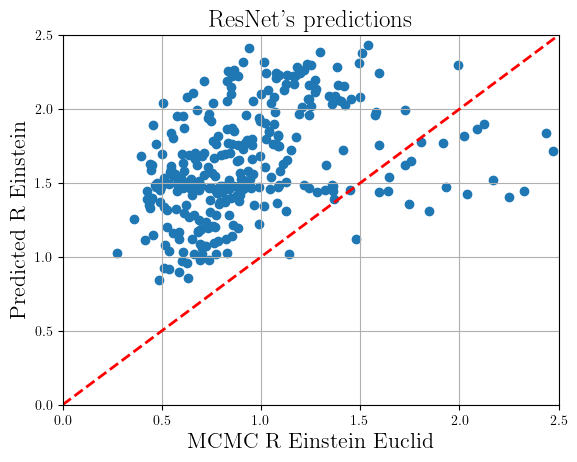

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]
# plt.scatter(df_final_2['Target_r_einstein'], df_final_2['Prediction_r_einstein'])
plt.scatter(
    df_final_2['einstein_radius_effective_max_lh'],
    df_final_2['pred_r_einstein_denorm']
)

# diagonal line (y = x)
x = np.linspace(0, 2.5, 100)
plt.plot(x, x, 'r--', linewidth=2)

plt.grid(True)
plt.xlabel('MCMC R Einstein Euclid', fontsize=16)
plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.title("ResNet's predictions", fontsize=18)
plt.ylabel('Predicted R Einstein', fontsize=16)

plt.show()

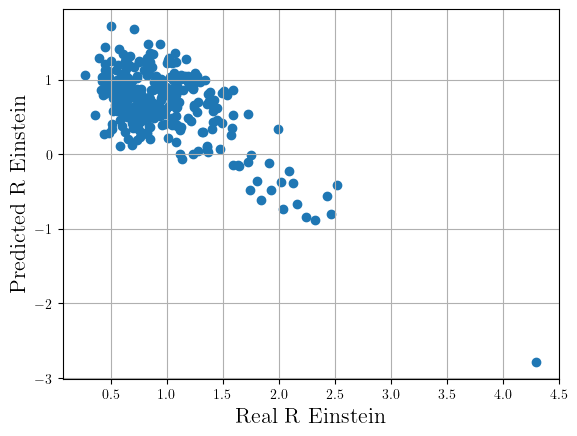

In [52]:
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

plt.scatter(df_final_2['einstein_radius_effective_max_lh'], df_final_2['pred_r_einstein_denorm'] - df_final_2['einstein_radius_effective_max_lh'])
# plt.scatter(df_final_2['Target_r_einstein'], df_final_2['Prediction_r_einstein'])
plt.grid(True)
plt.xlabel('Real R Einstein', fontsize = 16)
plt.ylabel('Predicted R Einstein', fontsize = 16)
plt.show()

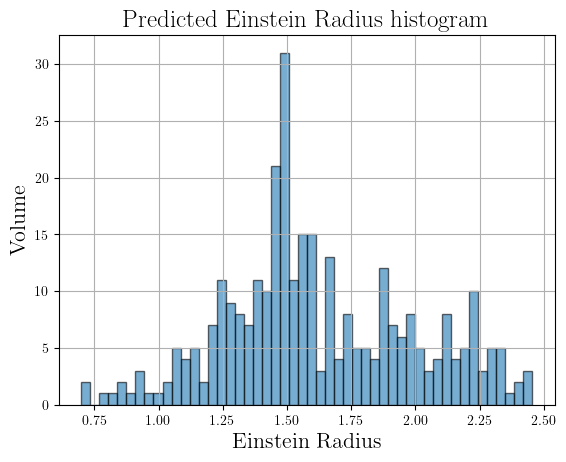

In [53]:
plt.hist(df_final_2['pred_r_einstein_denorm'], bins = 50, alpha = 0.6, edgecolor = 'black')
plt.title('Predicted Einstein Radius histogram', fontsize = 18)
plt.xlabel('Einstein Radius', fontsize = 16)
plt.ylabel('Volume', fontsize = 16)
plt.grid(True)
plt.show()

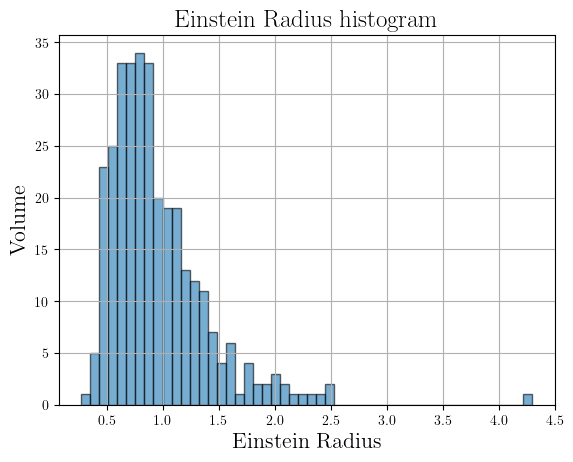

In [54]:
plt.hist(df_final_2['einstein_radius_effective_max_lh'], bins = 50, alpha = 0.6, edgecolor = 'black')
plt.title('Einstein Radius histogram', fontsize = 18)
plt.xlabel('Einstein Radius', fontsize = 16)
plt.ylabel('Volume', fontsize = 16)
plt.grid(True)
plt.show()

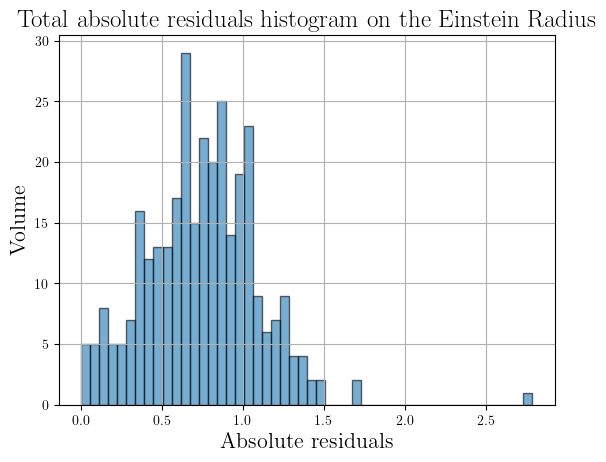

In [55]:
plt.hist(abs(df_final_2['einstein_radius_effective_max_lh'] - df_final_2['pred_r_einstein_denorm']), bins = 50, alpha = 0.6, edgecolor = 'black')
plt.title('Total absolute residuals histogram on the Einstein Radius', fontsize = 18)
plt.xlabel('Absolute residuals', fontsize = 16)
plt.ylabel('Volume', fontsize = 16)
plt.grid(True)
plt.show()

<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_242297/20477762.py:35: SyntaxWarning: invalid escape sequence '\s'
  f"$+ \sigma$ = {sigma_plus:.2f}\n"
/tmp/ipykernel_242297/20477762.py:36: SyntaxWarning: invalid escape sequence '\s'
  f"$- \sigma$ = {sigma_minus:.2f}"


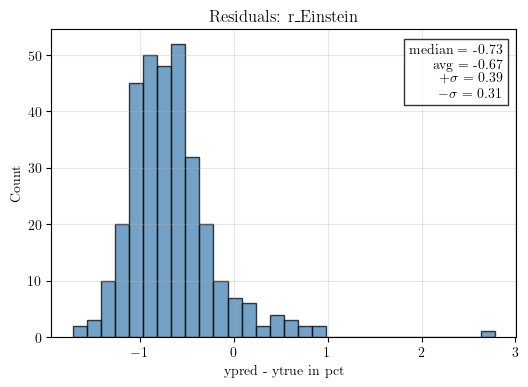

In [56]:
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# --- Compute denormalised errors ---
error_denorm = df_final_2['einstein_radius_effective_max_lh'] - df_final_2['pred_r_einstein_denorm']
# error_denorm = error_denorm/df_final_2['einstein_radius_effective_max_lh'] * 100

# error_denorm = df_final_2['Target_r_einstein'] - df_final_2['Prediction_r_einstein']

# --- Asymmetric statistics ---
medians = np.median(error_denorm)
p16 = np.percentile(error_denorm, 16)
p84 = np.percentile(error_denorm, 84)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# --- Plot ---
fig = plt.figure(figsize=(6, 4))

plt.hist(error_denorm, bins=30, alpha=0.75,
         color="steelblue", edgecolor="black")
plt.title(f"Residuals: {param_names[0]}")
plt.xlabel("ypred - ytrue in pct")
plt.ylabel("Count")
plt.grid(alpha=0.3)

# --- Add text box with denormalised stats ---
text = (
    f"median = {medians:.2f}%\n"
    f"avg = {np.mean(error_denorm):.2f}%\n"
    f"$+ \sigma$ = {sigma_plus:.2f}\n"
    f"$- \sigma$ = {sigma_minus:.2f}"
)

plt.text(
    0.97, 0.95, text,
    transform=plt.gca().transAxes,
    fontsize=10,
    ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
)

# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/unet_8_resnet_hist_residus.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
path_tensor = "/net/CLUSTER/VAULT/users/mbatt/data_euclid/"
full_dataset = LensDataset_euclid(df_paths_file, path_tensor)
test_loader = DataLoader(full_dataset, batch_size=32, shuffle=False, num_workers=3)

In [50]:
model.eval()
preds = []
targets = []
lens_only = []
paths = []

criterion = nn.MSELoss(reduction="none")
i = 0
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        if i < 3 :
            xb = xb.to(device)
            ybc, ps = yb[0].to(device), yb[1]
    
            out_lens = model.forward_unet(xb)
            outputs = model.forward_resnet(out_lens)
            
            preds.append(outputs.cpu())
            targets.append(ybc.cpu())
            paths += ps
            i += 1
        else:
            break
ddff = pd.DataFrame({'Objid' : ps, 'pred_einstein' : outputs.cpu().numpy()[:,0]})
# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)
df_final = pd.DataFrame({'Objid' : paths, 'Prediction_r_einstein' : preds.cpu().numpy()[:,0], 'Target_r_einstein' : targets.cpu().numpy()[:,0]})

/tmp/ipykernel_189886/121852211.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_189886/121852211.py:12: FutureWarning: You ar

In [51]:
ddff = ddff.merge(modeling_lens_mass[['id_str', 'einstein_radius_effective_max_lh']], left_on = 'Objid', right_on = 'id_str', how = 'left')
ddff['pred_einstein'] = ddff['pred_einstein'] * (df_max[0] - df_min[0]) + df_min[0]
ddff = ddff.dropna()
ddff = ddff[ddff['pred_einstein'] != 0]
del ddff['Objid']
ddff.index = ddff['id_str']
del ddff['id_str']

/tmp/ipykernel_189886/1669242606.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(path_tensor + paths[k] + '.pt')


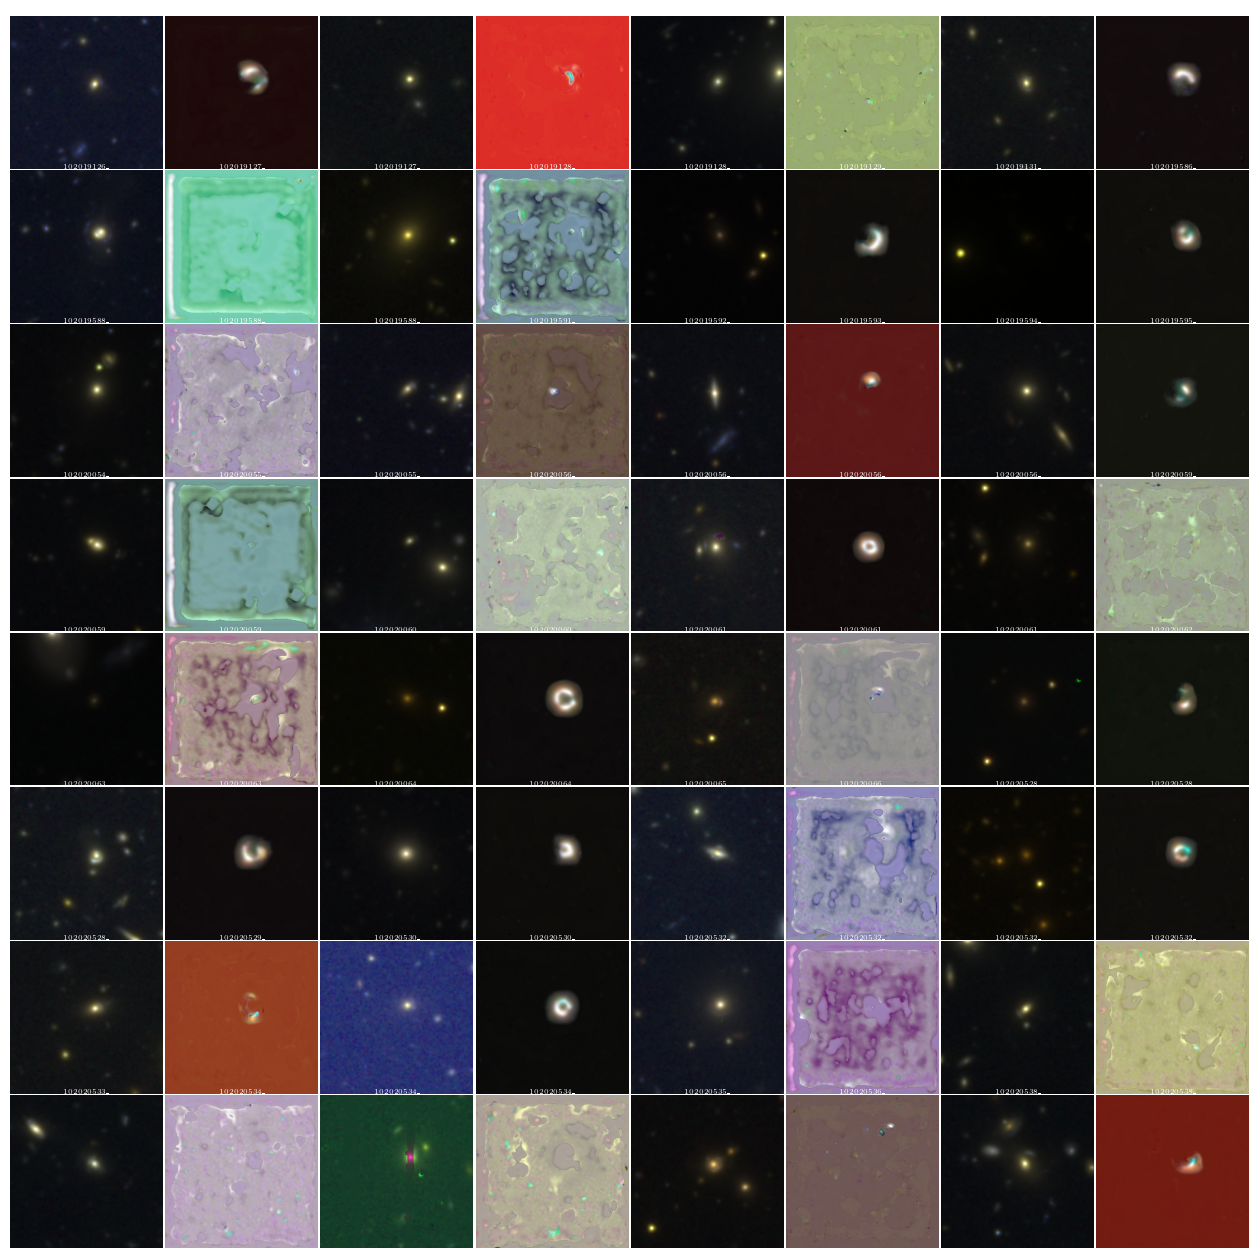

In [54]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

def showswho(imgi):
    L = []
    for i in range(3):
        img = imgi[:,:,i]
        img = np.nan_to_num(img)
        # p1, p99 = np.percentile(img, [0, 99.996])
        p1, p99 = np.percentile(img, [0, 99.996])
        if p99 > p1:
            img = np.clip(img, p1, p99)
            img = (img - p1) / (p99 - p1)
        else:
            img[:] = 0
        img = np.sqrt(img)
        L.append(img)
    return np.dstack(L)

path_tensor = "/net/CLUSTER/VAULT/users/mbatt/data_euclid/"
images = []

for k in range(32):
    x = torch.load(path_tensor + paths[k] + '.pt')
    x = x.numpy()
    # x = abs(x)
    # x = x[3]
    x = np.dstack([x[0], x[1], x[-1]])
    # images.append(x)
    images.append(showswho(x))

    y = out_lens[k].cpu().numpy()
    # y = np.dstack([y[0], y[1], y[-1]])
    y = np.dstack([y[0],y[1], y[-1]])
    # y = abs(y)
    # y = y**2
    # y = y[3]
    # images.append(1/y)
    images.append(showswho(y))
    # images.append(abs(y))
    
    
# --- Plot ---
ncols, nrows = 8, 8
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))
plt.subplots_adjust(wspace=0.01, hspace=0.01)

for ax in axes.flat:
    ax.axis("off")

for i, ax in enumerate(axes.flat):
    if i < len(images):
        if i%2 !=0:
            im = ax.imshow(images[i], origin="lower")
        else:
            im = ax.imshow(images[i], origin="lower")
        ax.set_title(labels[i][:10], fontsize=5, pad=1, color="white")  # optional ID label
        # plt.colorbar(im, ax=ax)

# plt.savefig("euclid_color_grid.png", dpi=150, bbox_inches="tight",
#             facecolor="black")
# plt.colorbar(images[i], orientation='vertical', pad=0.01, fraction=0.04)
plt.show()

In [55]:
ddff['residual'] = ddff['pred_einstein'] - ddff['einstein_radius_effective_max_lh']
ddff

,pred_einstein,einstein_radius_effective_max_lh,residual
id_str,,,
102020539_NEG639239120489296299,2.194718,1.418634,0.776084
102020539_NEG640534948489252606,1.189602,0.814877,0.374725
102020539_NEG641383802490968352,1.018171,0.681124,0.337047
102021006_NEG554672577486973111,2.006841,0.829341,1.177500
102021008_NEG569571426487440793,1.018793,0.592537,0.426257
102021009_NEG577024787484062221,1.019838,2.323862,-1.304024
102021010_NEG581199679484613010,2.238004,1.204348,1.033656
102021012_NEG594963796484947260,1.367459,1.756304,-0.388845
102021013_NEG602940269483238112,1.020283,1.181791,-0.161508


In [ ]:
ybc.shape


In [ ]:
u = torch.load(path_tensor + paths[k] + '.pt')
for uu in u:
    print(uu.mean())

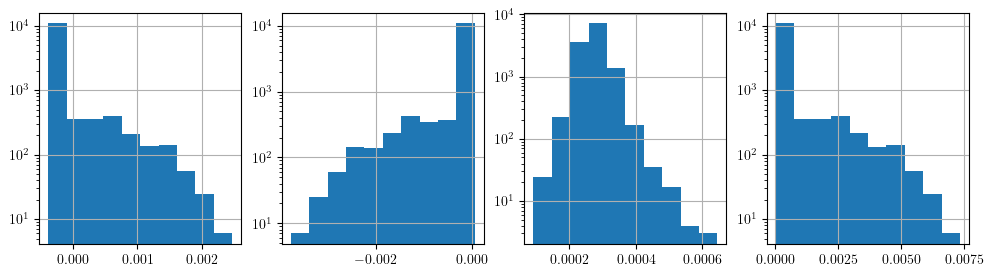

In [179]:
fig, axes = plt.subplots(1,4, figsize = (12,3))
for j in range(4):
    ax = axes[j]
    ax.hist(out_lens[0][j].cpu().numpy().flatten(), log = True)
    ax.grid(True)
plt.show()

In [44]:
for k in range(4):
    print(showswho(y)[k].mean())

0.40845707
0.45104158
0.4458056
0.4488421


In [57]:
def rms(x):
    return torch.sqrt(torch.mean(x**2, dim=(-2, -1)))

def compute_noise(Liste, image, squarre):
    # Extract 5x5 corners
    tl = image[..., 0:squarre, 0:squarre]
    tr = image[..., 0:squarre, -squarre:]
    bl = image[..., -squarre:, 0:squarre]
    br = image[..., -squarre:, -squarre:]

    # RMS per corner → [B, 4]
    rms_tl = rms(tl)
    rms_tr = rms(tr)
    rms_bl = rms(bl)
    rms_br = rms(br)

    # Stack → [B, 4, 4]
    rms_all = torch.stack([rms_tl, rms_tr, rms_bl, rms_br], dim=-1)

    # Minimum RMS across corners → [B, 4]
    rms_min = rms_all.min(dim=-1).values

    Liste.append(rms_min.cpu())
    return Liste

In [58]:
model.eval()

Noise_t = []
Noise_p = []
Signal_t = []
Signal_p = []

squarre = 20
criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb, _ = yb[0].to(device), yb[1]

        optimizer.zero_grad()
        # ---- Forward pass ----
        out_lens = model.forward_unet(xb)
        outputs = model.forward_resnet(out_lens)
        Noise_t = compute_noise(Noise_t, xb, squarre)
        signal_batch = xb.sum(dim=(-1, -2))
        Signal_t.append(signal_batch.cpu())
# Concatenate all batches
Noise_t = torch.cat(Noise_t, dim=0) 
Signal_t = torch.cat(Signal_t, dim=0) # shape [N, 4]
# Compute ratio
Ratio_t = Signal_t / Noise_t

/tmp/ipykernel_2789/630939183.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_2789/630939183.py:12: FutureWarning: You are us

In [80]:
model.eval()
preds = []
targets = []
lens_only = []
paths = []

criterion = nn.MSELoss(reduction="none")
i = 0
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here

        xb = xb.to(device)
        yb, ps = yb[0].to(device), yb[1]

        out_lens = model.forward_unet(xb)
        outputs = model.forward_resnet(out_lens)
        
        preds.append(outputs.cpu())
        targets.append(yb.cpu())
        paths += ps
        i += 1

            
# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)
df_final = pd.DataFrame({'Objid' : paths, 'Prediction_r_einstein' : preds.cpu().numpy()[:,0], 'Target_r_einstein' : targets.cpu().numpy()[:,0]})

/tmp/ipykernel_112088/630939183.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_112088/630939183.py:12: FutureWarning: You ar

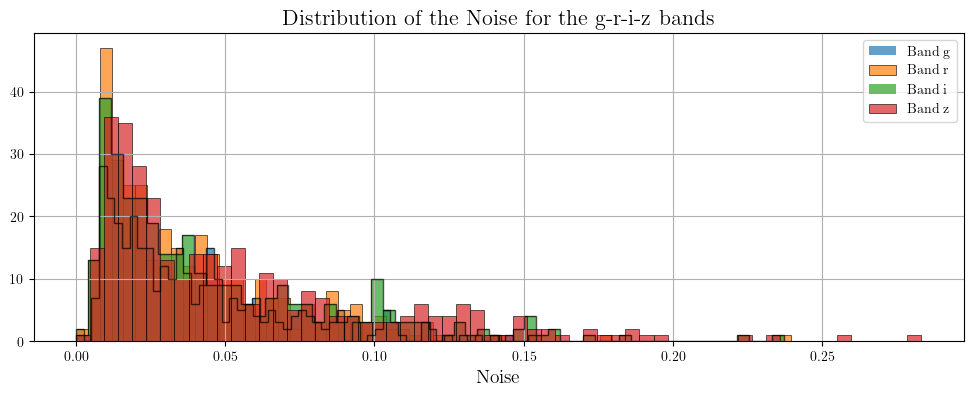

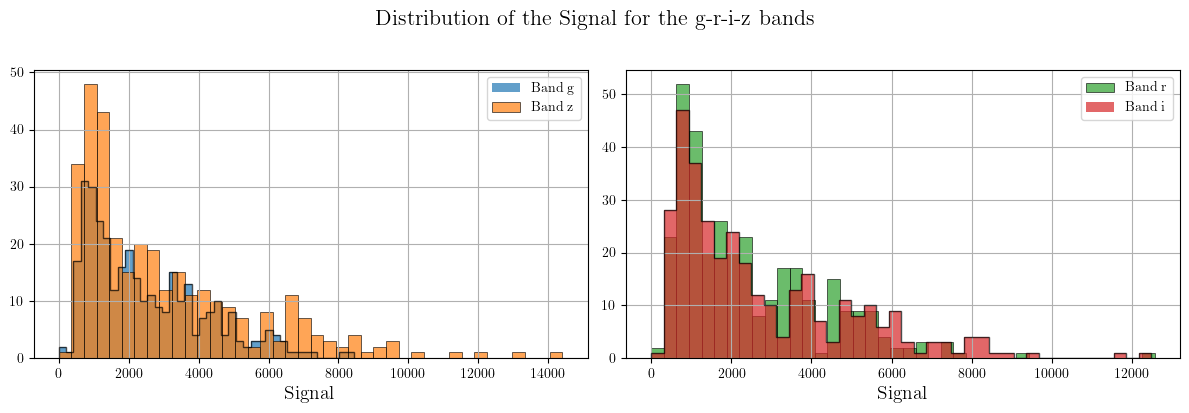

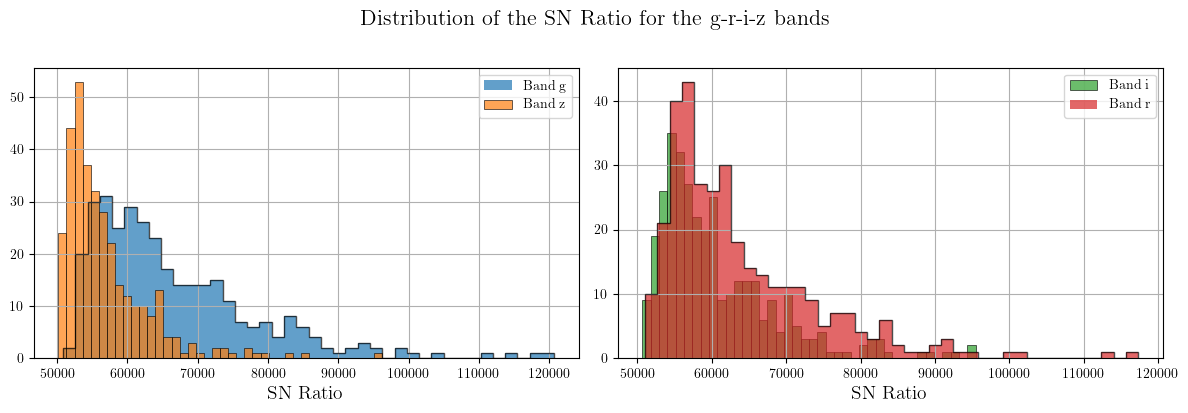

In [64]:
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]


fig, axis = plt.subplots(1,1, figsize = (12,4))
bandes = ['g', 'r', 'i', 'z']
binss = 40
bins_s = 60

ax = axis
# counts, bins, _ = ax.hist(Noise_t[:,0][Noise_t[:,0] < 0.6], bins=200, alpha=0.7, label = f'Band {bandes[0]}',histtype='step')
# # result = [x for x in bins[1:] for _ in range(2)]
# ax.plot(bins[:-1], counts, color='black', linewidth=0.7)
ax.hist(Noise_t[:,0], bins=bins_s, alpha=0.7, label = f'Band {bandes[0]}')
ax.hist(Noise_t[:,0], bins=bins_s, alpha=0.7, histtype='step', linewidth = 1, color = 'black')

ax.hist(Noise_t[:,1], bins= bins_s, label = f'Band {bandes[1]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

ax.hist(Noise_t[:,2], bins=bins_s, alpha=0.7, label = f'Band {bandes[2]}')
ax.hist(Noise_t[:,2], bins=bins_s, alpha=0.7, histtype='step', linewidth = 1, color = 'black')

ax.hist(Noise_t[:,3][Noise_t[:,3] < 0.3], bins= bins_s, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

ax.set_title(f"Distribution of the Noise for the g-r-i-z bands",fontsize=16)
ax.grid(True)
ax.set_xlabel('Noise', fontsize=14)
ax.legend()
plt.show()

fig, axis = plt.subplots(1,2, figsize = (12,4))
ax = axis[0]
ax.hist(Signal_t[:,0], bins=binss, alpha=0.7, label = f'Band {bandes[0]}')
ax.hist(Signal_t[:,0], bins=binss, alpha=0.7, histtype='step', linewidth = 1, color = 'black')

ax.hist(Signal_t[:,3][Signal_t[:,3] <15000], bins= binss, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
ax.grid(True)
ax.set_xlabel('Signal', fontsize=14)
ax.legend()

ax = axis[1]

ax.hist(Signal_t[:,1], bins= binss, color = '#2ca02c', label = f'Band {bandes[1]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

ax.hist(Signal_t[:,2],color = '#d62728', bins=binss, alpha=0.7, label = f'Band {bandes[2]}')
ax.hist(Signal_t[:,2], bins=binss, alpha=0.7, histtype='step', linewidth = 1, color = 'black')


ax.grid(True)
ax.set_xlabel('Signal',fontsize=14)
ax.legend()

fig.suptitle("Distribution of the Signal for the g-r-i-z bands",
             fontsize=16, y=1.02)
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/sn_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axis = plt.subplots(1,2, figsize = (12,4))
ax = axis[0]
ax.hist(Ratio_t[:,0], bins=binss, alpha=0.7, label = f'Band {bandes[0]}')
ax.hist(Ratio_t[:,0], bins=binss, alpha=0.7, histtype='step', linewidth = 1, color = 'black')
ax.hist(Ratio_t[:,3], bins= binss, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
ax.grid(True)
ax.set_xlabel('SN Ratio', fontsize=14)
ax.legend()

ax = axis[1]
ax.hist(Ratio_t[:,2], bins= binss, color = '#2ca02c', label = f'Band {bandes[2]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
ax.hist(Ratio_t[:,1],color = '#d62728', bins=binss, alpha=0.7, label = f'Band {bandes[1]}')
ax.hist(Ratio_t[:,1], bins=binss, alpha=0.7, histtype='step', linewidth = 1, color = 'black')
ax.grid(True)
ax.set_xlabel('SN Ratio',fontsize=14)
ax.legend()

fig.suptitle("Distribution of the SN Ratio for the g-r-i-z bands",
             fontsize=16, y=1.02)
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/sn_ratio.png", dpi=300, bbox_inches="tight")
plt.show()
    